In [62]:
import numpy as np
import pandas as pd

In [63]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [64]:
x_train.shape

(60000, 28, 28)

In [65]:
#60000 is no. of images in dataset.
#each image has 28x28 pixels. (i.e) each image has 28 rows & 28 columns.

In [66]:
x_test.shape

(10000, 28, 28)

In [67]:
#Just see how it looks like
#x_train

### Pre-processing

In [68]:
#60,000 images with one channel (the “1” represents grayscale)
# [0] extracts the first element of the tuple, which is 60000.This ensures the reshape keeps the same number of samples, no matter how many you have.
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

#while flattening, each 24x24 is converted into singe row with 784 colums.
#it means each image is converted as single row with 784 columns.
#so, totally for 60000 rows & 784 columns.

In [69]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [70]:
#In MNIST, each pixel intensity is an integer between 0 and 255 (0 = black, 255 = white)
#Dividing by 255 scales all values into the range 0.0 to 1.0.
x_train /=255
x_test /=255

### Model creation

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
model = Sequential()
#Convolution layer
model.add(Conv2D(28, kernel_size=(3,3), input_shape = input_shape))
#28 is no. of filter or channel depth
#size of filter is 3x3
#no. of strides & activation functions are default values.
##Maxpooling
model.add(MaxPooling2D(pool_size = (2,2)))# 2x2 size
model.add(Flatten())
## Neural networks starts below after flattening
model.add(Dense(128, activation=tf.nn.relu)) #128 is no. of neurons in first dense layer
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))#10 is no. of classes in output.

In [72]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 28)        280       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 13, 13, 28)       0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 4732)              0         
                                                                 
 dense_4 (Dense)             (None, 128)               605824    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                      

### Compiling & fitting the model

In [73]:
model.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model = model.fit(x=x_train,y=y_train, epochs=10, validation_data = (x_test, y_test))
# epoch means action of feed forward and back probagation for entire dataset. we are doing this 10 times here


Epoch 1/10
1875/1875 [==============================] - 38s 20ms/step - loss: 0.2078 - accuracy: 0.9377 - val_loss: 0.0807 - val_accuracy: 0.9748
Epoch 2/10
1875/1875 [==============================] - 39s 21ms/step - loss: 0.0840 - accuracy: 0.9741 - val_loss: 0.0629 - val_accuracy: 0.9801
Epoch 3/10
1875/1875 [==============================] - 40s 21ms/step - loss: 0.0595 - accuracy: 0.9815 - val_loss: 0.0541 - val_accuracy: 0.9828
Epoch 4/10
1875/1875 [==============================] - 40s 21ms/step - loss: 0.0442 - accuracy: 0.9856 - val_loss: 0.0529 - val_accuracy: 0.9855
Epoch 5/10
1875/1875 [==============================] - 42s 23ms/step - loss: 0.0354 - accuracy: 0.9886 - val_loss: 0.0494 - val_accuracy: 0.9860
Epoch 6/10
1875/1875 [==============================] - 40s 22ms/step - loss: 0.0289 - accuracy: 0.9905 - val_loss: 0.0578 - val_accuracy: 0.9844
Epoch 7/10
1875/1875 [==============================] - 40s 21ms/step - loss: 0.0254 - accuracy: 0.9912 - val_loss: 0.0593 -

### Model evaluation

In [74]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 2s 6ms/step - loss: 0.0606 - accuracy: 0.9853


[0.06058044359087944, 0.9853000044822693]

### Predict the output for test data

In [75]:
y_predict = model.predict(x_test)
#choose the max value from 10 values each output.
y_predicts = np.argmax(y_predict, axis=1)
y_predicts

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [76]:
#actual test output is already in the right format.
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

### Confusion matrix

In [77]:
from sklearn.metrics import confusion_matrix
con_mat = confusion_matrix(y_test, y_predicts)

In [78]:
con_mat

array([[ 974,    0,    1,    0,    0,    0,    2,    1,    1,    1],
       [   0, 1132,    1,    0,    0,    0,    1,    0,    1,    0],
       [   1,    0, 1023,    1,    1,    0,    1,    3,    1,    1],
       [   0,    0,    4,  997,    0,    4,    0,    2,    0,    3],
       [   0,    0,    3,    0,  956,    0,    3,    1,    3,   16],
       [   3,    0,    0,    9,    0,  877,    2,    0,    1,    0],
       [   7,    3,    0,    1,    4,    2,  938,    0,    3,    0],
       [   2,    4,    8,    1,    0,    0,    0, 1008,    2,    3],
       [   5,    0,    2,    6,    0,    1,    1,    3,  953,    3],
       [   1,    1,    0,    4,    3,    2,    0,    3,    0,  995]],
      dtype=int64)

### Let's viualize the confusion matrix in Heat map

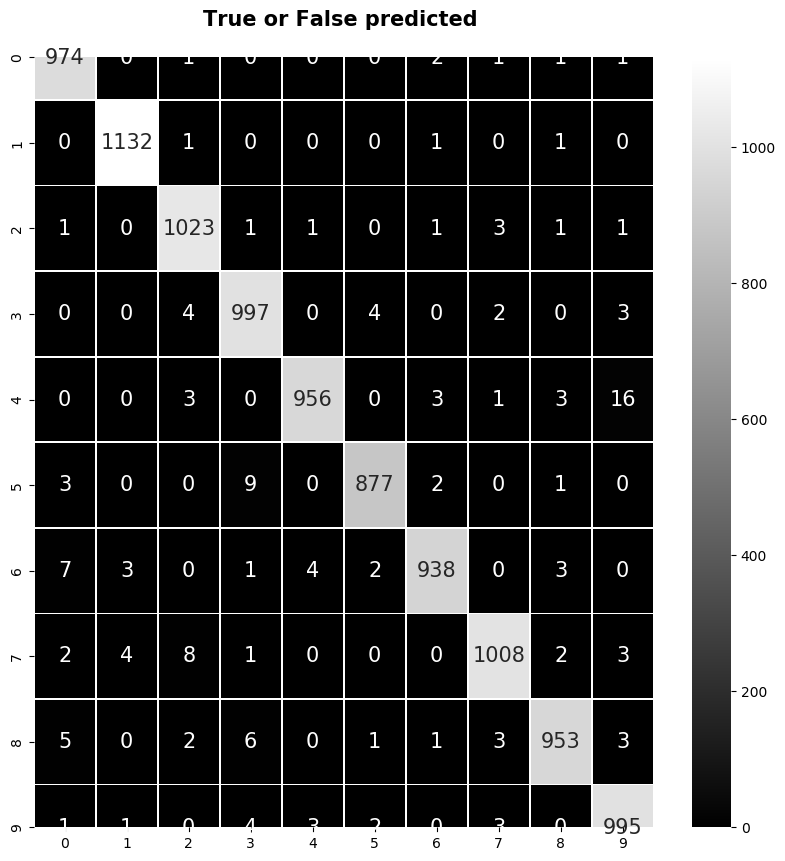

In [79]:
#Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

plt.style.use('seaborn-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True, annot_kws={'size' :15}, linewidths=0.5, fmt="d", cmap ="gray")
plt.title('True or False predicted \n', fontweight ='bold', fontsize=15)
plt.show()

### Classification report 

In [80]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predicts))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.98      0.98       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.97      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [81]:
#Overall Accuracy is 0.99

### Accuracy Vs Epochs & Loss Vs Epochs

In [82]:
print(cnn_model.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


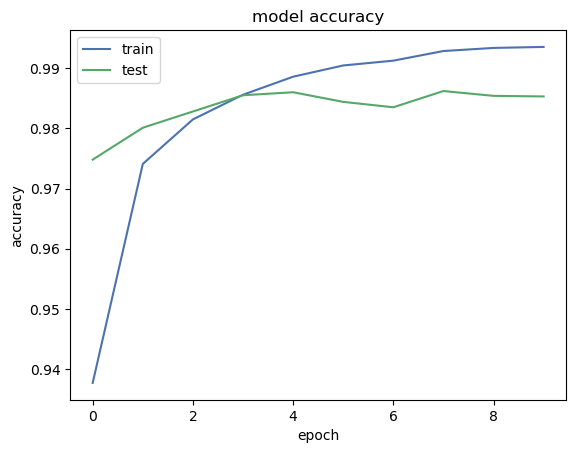

In [83]:
#Summarize the model for accuracy.
plt.plot(cnn_model.history['accuracy'])
plt.plot(cnn_model.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

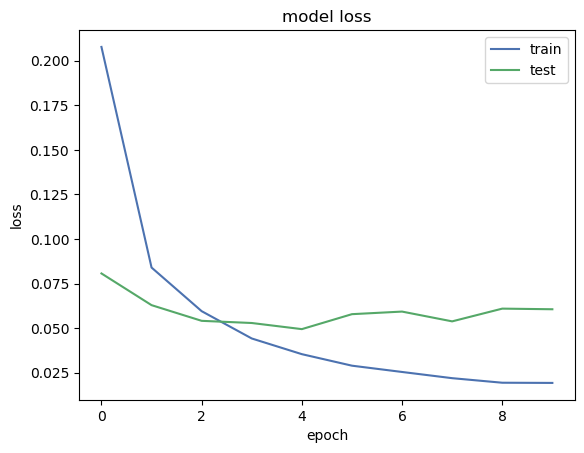

In [84]:
#Summarize the history for loss.

plt.plot(cnn_model.history['loss'])
plt.plot(cnn_model.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

### Deployment check for single input from test data

The predicted image label is 6


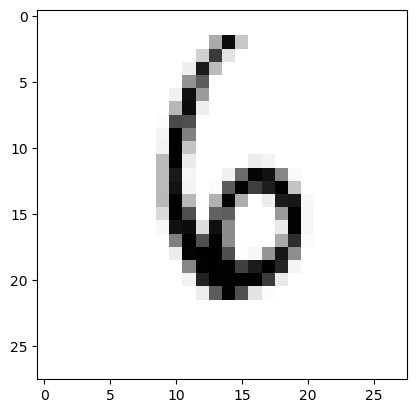

In [85]:
image_index = 6900 # choosing 6900th position
plt.imshow(x_test[image_index].reshape(28,28),cmap='Greys') # Display that 6900th image from test_input data. reshaping to 3D back.

pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))# we are going predict the same image from test input data using our created model

#reshape(1, 28, 28, 1) → adds a batch dimension (the 1 means “one image”).
#CNNs expect input in the form (batch_size, height, width, channels).
#So here: (1, 28, 28, 1) → one grayscale image.

print(f'The predicted image label is {pred.argmax()}')